<a href="https://colab.research.google.com/github/vothanhly14/AI_Assignments_1/blob/main/AI_Assignments_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#BÀI TẬP
#23.1. Sử dụng thư viện Folium, bạn hãy xây dựng một bản đồ tương tác hiển thị vị trí của UEH hoặc trường Đại học đang theo học hoặc một địa điểm trung tâm được lựa chọn. Trên bản đồ cần thể hiện tối thiểu năm địa điểm công cộng lân cận như bệnh viện, trung tâm thương mại, bến xe hoặc cơ quan hành chính. Mỗi địa điểm phải được gần marker có popup mô tả ngắn gọn thông tin. Bản đồ cần có khả năng phóng to, thu nhỏ và bật/tắt các lớp dữ liệu.
import folium

m = folium.Map(location=[10.7600, 106.6645], zoom_start=15)

fg_ueh = folium.FeatureGroup(name='Vị trí UEH')
fg_lan_can = folium.FeatureGroup(name='Địa điểm lân cận')

folium.Marker(
    [10.7600, 106.6645],
    popup="Đại học UEH - Cơ sở Nguyễn Tri Phương",
    tooltip="Trung tâm"
).add_to(fg_ueh)

locations = [
    ([10.7578, 106.6612], "Bệnh viện Chợ Rẫy"),
    ([10.7548, 106.6625], "The Garden Mall"),
    ([10.7585, 106.6685], "Công viên Hòa Bình"),
    ([10.7562, 106.6631], "Đại học Y Dược"),
    ([10.7621, 106.6598], "Chợ Thiếc")
]

for loc, name in locations:
    folium.Marker(
        location=loc,
        popup=name,
    ).add_to(fg_lan_can)

fg_ueh.add_to(m)
fg_lan_can.add_to(m)

folium.LayerControl().add_to(m)

m

In [8]:
#23.2. Sử dụng GeoPy, bạn hãy thu thập hoặc giả lập danh sách tối thiểu mười địa chỉ cụ thể. Thực hiện chuyển đổi các địa chỉ này sang tọa độ địa lý (vĩ độ, kinh độ) và tỉnh khoảng cách từ mỗi địa chỉ đến một điểm trung tâm xác định trước. Kết quả cần được trực quan hóa trên bàn khoảng cách và mối quan hệ không gian điểm.
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium

geolocator = Nominatim(user_agent="geoapi_ex")
ueh_center = (10.7600, 106.6645)

addresses = [
    "Chợ Bến Thành, Quận 1, TP.HCM",
    "Dinh Độc Lập, Quận 1, TP.HCM",
    "Nhà thờ Đức Bà, Quận 1, TP.HCM",
    "Bưu điện Thành phố, Quận 1, TP.HCM",
    "Phố đi bộ Nguyễn Huệ, Quận 1, TP.HCM",
    "Landmark 81, Bình Thạnh, TP.HCM",
    "Bảo tàng Chứng tích Chiến tranh, Quận 3, TP.HCM",
    "Hồ Con Rùa, Quận 3, TP.HCM",
    "Nhà hát Thành phố, Quận 1, TP.HCM",
    "Thảo Cầm Viên, Quận 1, TP.HCM"
]

m = folium.Map(location=ueh_center, zoom_start=13)
folium.Marker(ueh_center, popup="UEH Center", icon=folium.Icon(color='red')).add_to(m)

print("Kết quả tính khoảng cách:")
for addr in addresses:
    location = geolocator.geocode(addr)
    if location:
        point = (location.latitude, location.longitude)
        dist = geodesic(ueh_center, point).km
        print(f"- {addr}: {dist:.2f} km")
        folium.Marker(point, popup=f"{addr}: {dist:.2f}km").add_to(m)

m

Kết quả tính khoảng cách:
- Chợ Bến Thành, Quận 1, TP.HCM: 4.35 km
- Bưu điện Thành phố, Quận 1, TP.HCM: 4.42 km
- Landmark 81, Bình Thạnh, TP.HCM: 10.25 km
- Nhà hát Thành phố, Quận 1, TP.HCM: 4.63 km
- Thảo Cầm Viên, Quận 1, TP.HCM: 5.52 km


In [12]:
#23.3. Bạn hãy tạo một bản đồ nhiệt (heatmap) thể hiện mật độ phân bố của một hiện tượng không gian như khách hàng, đơn hàng, dân cư hoặc điểm giao dịch (dữ liệu có thể giả lập). Bản đồ phải cho phép người xem nhận biết trực quan các khu vực có mật độ cao và thấp, đồng thời giải thích ý nghĩa quản trị của các vùng nóng trên bản đồ.
import folium
from folium.plugins import HeatMap
import numpy as np

center_hcm = [10.776, 106.700]
m = folium.Map(location=center_hcm, zoom_start=13)

# Tạo một cụm mật độ cao (Vùng nóng - Quận 1)
vung_1 = [[10.776 + np.random.uniform(-0.005, 0.005),
           106.700 + np.random.uniform(-0.005, 0.005)] for _ in range(70)]

# Tạo một cụm mật độ thấp (Vùng lạnh - Quận 3)
vung_2 = [[10.785 + np.random.uniform(-0.01, 0.01),
           106.685 + np.random.uniform(-0.01, 0.01)] for _ in range(30)]

data_don_hang = vung_1 + vung_2

HeatMap(data_don_hang).add_to(m)

folium.Marker(
    location=[10.776, 106.700],
    popup="VÙNG NÓNG: Mật độ đơn hàng cao nhất",
    tooltip="Ý nghĩa quản trị: Ưu tiên điều phối nhân sự tại đây",
    icon=folium.Icon(color='red', icon='fire') # icon hình ngọn lửa cho đúng chất "nóng"
).add_to(m)

m

In [25]:
#23.4. Sử dụng GeoPandas, hãy đọc dữ liệu ranh giới hành chính (tỉnh, thành phố hoặc phường/xã) và kết hợp với một tập dữ liệu số tương ứng như dân số, doanh thu, số lượng đơn hàng hoặc mức độ tiêu thụ. Kết quả cần được thể hiện dưới dạng bản đồ choropleth, phản ánh sự khác biệt không gian giữa các khu vực và đưa ra nhận xét ngắn về ý nghĩa quản trị.
import geopandas as gpd
import folium
import pandas as pd

url_us_geo = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"
us_states_gdf = gpd.read_file(url_us_geo)

# Cột 'State_Code' phải khớp với thuộc tính 'id' trong file GeoJSON (AL, AK, AZ,...)
data_sales = pd.DataFrame({
    'State_Code': ['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'WA'],
    'Sales_Amount': [5000, 4500, 3800, 3200, 2500, 2100, 1800, 1900, 1700, 2300]
})

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

folium.Choropleth(
    geo_data=url_us_geo,             # Link dữ liệu ranh giới
    name="Choropleth Doanh Thu US",
    data=data_sales,                 # Dữ liệu số từ Pandas
    columns=["State_Code", "Sales_Amount"],
    key_on="feature.id",             # Nối cột 'State_Code' với 'id' của bang (ví dụ: 'CA')
    fill_color="YlOrRd",             # Bảng màu: Vàng (thấp) -> Đỏ (cao)
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Doanh số bán hàng theo Bang (nghìn USD)"
).add_to(m)

folium.LayerControl().add_to(m)

m

In [32]:
#23.5. Bạn hãy xây dựng mô hình phân tích vùng phục vụ (service area) cho một trung tâm phân phối, kho hàng hoặc trạm dịch vụ. Sử dụng dữ liệu tọa độ đề về các vòng bản kính phục vụ khác nhau (ví dụ: 3 km, 5 km và 10 km) và trực quan hóa trên bản đồ. Bài làm cần đánh giá khả năng tiếp cận khách hàng của từng vùng và đề xuất phạm vi hoạt động tối ưu.
import folium

center_loc = [10.7600, 106.6645] # Giả sử kho tại UEH
m = folium.Map(location=center_loc, zoom_start=13)

service_areas = [
    {"radius": 10000, "color": "red", "name": "Vùng ngoại vi"},
    {"radius": 5000, "color": "green", "name": "Vùng tiêu chuẩn"},
    {"radius": 3000, "color": "blue", "name": "Vùng ưu tiên"}
]

folium.Marker(center_loc, popup="TRUNG TÂM PHÂN PHỐI", icon=folium.Icon(color='black', icon='house')).add_to(m)

for area in service_areas:
    folium.Circle(
        location=center_loc,
        radius=area["radius"],
        color=area["color"],
        fill=True,
        fill_opacity=0.1,
        popup=f"{area['name']}: {area['radius']/1000} km",
        tooltip=f"Click xem chi tiết vùng {area['radius']/1000}km"
    ).add_to(m)

m

In [34]:
#23.6. Sử dụng OSMnx, bạn hãy tải dữ liệu mạng lưới giao thông đường bộ của một khu vực đô thị cụ thể. Trực quan hóa mạng đường trên bản đồ và thực hiện một số phân tích cơ bản như số lượng nút giao, chiều dài đường trung bình hoặc mật độ mạng. Trình bày vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh.
!pip install folium geopy osmnx networkx

Số lượng nút giao: 989
Số lượng đoạn đường: 2090
Chiều dài trung bình: 79.03 mét


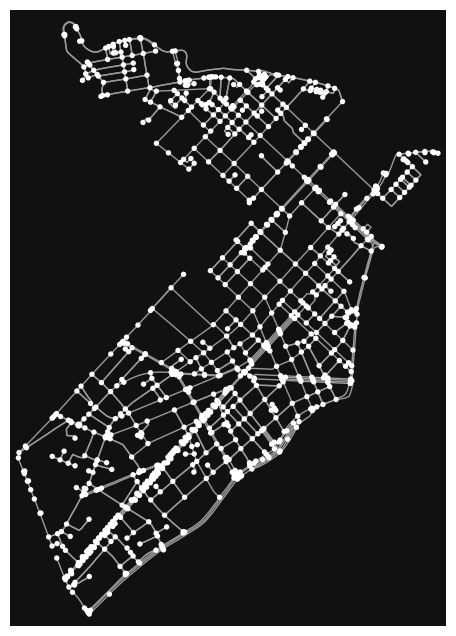

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [35]:
import osmnx as ox

place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')

nodes, edges = ox.graph_to_gdfs(G)
print(f"Số lượng nút giao: {len(nodes)}")
print(f"Số lượng đoạn đường: {len(edges)}")
print(f"Chiều dài trung bình: {edges['length'].mean():.2f} mét")

ox.plot_graph(G)

Độ dài Dijkstra: 601.68m
Độ dài A*: 601.68m


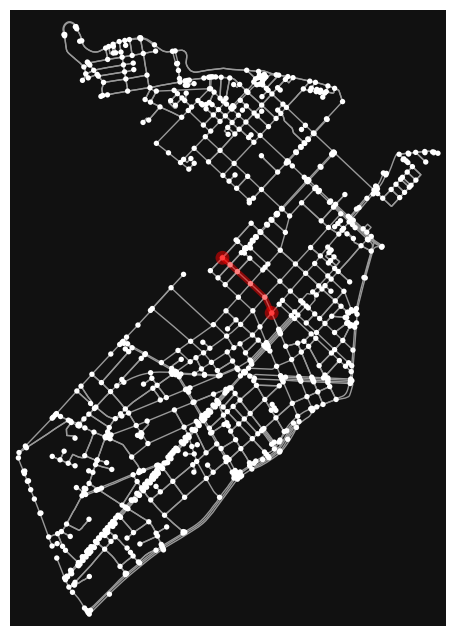

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [36]:
#23.7. Kết hợp OSMnx và NetworkX, bạn hãy xây dựng chương trình tìm đường đi ngân nhất giữa hai địa điểm bất kỳ trong khu vực nghiên cứu. So sánh kết quả giữa ít nhất hai thuật toán khác nhau (ví dụ: Dijkstra và A*). Tuyến đường tìm được cần được hiển thị trực quan trên bản đồ và phân tích ưu – nhược điểm của từng phương pháp.
import osmnx as ox
import networkx as nx

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive')

origin = (10.776, 106.700) # Gần chợ Bến Thành
destination = (10.782, 106.695) # Gần nhà thờ Đức Bà

orig_node = ox.distance.nearest_nodes(G, origin[1], origin[0])
dest_node = ox.distance.nearest_nodes(G, destination[1], destination[0])

route_dijkstra = nx.shortest_path(G, orig_node, dest_node, weight='length')
route_astar = nx.astar_path(G, orig_node, dest_node, weight='length')

len_d = nx.path_weight(G, route_dijkstra, weight='length')
len_a = nx.path_weight(G, route_astar, weight='length')

print(f"Độ dài Dijkstra: {len_d:.2f}m")
print(f"Độ dài A*: {len_a:.2f}m")

ox.plot_graph_route(G, route_dijkstra, route_color='r')

In [44]:
#23.8. Bạn hãy mô phỏng một hệ thống gọi xe công nghệ đơn giản. Trong đó, vị trí khách hàng và xe được biểu diễn băng tọa độ trên bản đồ. Áp dụng một phương pháp Al hoặc heuristic để gán xe phù hợp nhất cho từng khách hàng dựa trên khoảng cách hoặc thời gian di chuyền Toàn bộ quá trình ghép xe và khách cần được trực quan hóa trên bản đồ.
import folium
from geopy.distance import distance

customer_coords = (10.770, 106.690)
drivers = {
    "Tài xế A": (10.779, 106.700),
    "Tài xế B": (10.755, 106.685),
    "Tài xế C": (10.782, 106.675)
}

nearest_name, nearest_coords = min(drivers.items(), key=lambda x: distance(customer_coords, x[1]).km)
min_dist = distance(customer_coords, nearest_coords).km

m = folium.Map(location=customer_coords, zoom_start=13)

folium.Marker(
    location=customer_coords,
    popup="KHÁCH HÀNG",
    icon=folium.Icon(color='blue', icon='user', prefix='fa')
).add_to(m)

for name, pos in drivers.items():
    if name == nearest_name:
        color = 'red'
        status = "Đã kết nối"
    else:
        color = 'gray'
        status = "Đang chờ"

    folium.Marker(
        location=pos,
        popup=f"{name} ({status})",
        icon=folium.Icon(color=color, icon='car', prefix='fa')
    ).add_to(m)

folium.PolyLine(
    locations=[customer_coords, nearest_coords],
    color='red',
    weight=3,
    dash_array='5, 5',
    tooltip=f"Khoảng cách ghép nối: {min_dist:.2f} km"
).add_to(m)

print(f"Hệ thống đã ghép nối khách hàng với {nearest_name}")
print(f"Khoảng cách Heuristic: {min_dist:.2f} km")
m

Hệ thống đã ghép nối khách hàng với Tài xế A
Khoảng cách Heuristic: 1.48 km


In [45]:
#23.9. Sử dụng thuật toán phân cụm trong học máy, bạn hãy phân cụm dữ liệu vị trí khách hàng hoặc đơn hàng. Trên cơ sở kết quả phân cụm, đề xuất vị trí đặt trạm xe, kho hàng hoặc điểm trung chuyển tối ưu. Kết quả phân tích phải được trình bày dưới dạng bản đồ và có giải thích logic quản trị đi kèm.
import pandas as pd
from sklearn.cluster import KMeans
import folium

# Giả lập tọa độ 20 khách hàng
data = {
    'lat': [10.77, 10.78, 10.75, 10.76, 10.79, 10.74, 10.775, 10.782, 10.755, 10.765] * 2,
    'lon': [106.69, 106.70, 106.68, 106.67, 106.71, 106.66, 106.695, 106.705, 106.685, 106.675] * 2
}
df = pd.DataFrame(data)

#Áp dụng K-Means để chia làm 3 cụm (3 kho hàng)
kmeans = KMeans(n_clusters=3, random_state=0).fit(df)
df['cluster'] = kmeans.labels_
centers = kmeans.cluster_centers_

m = folium.Map(location=[10.77, 106.69], zoom_start=13)
for i, center in enumerate(centers):
    folium.Marker(center, popup=f"Vị trí đặt kho {i+1}", icon=folium.Icon(color='red', icon='star')).add_to(m)

m

In [49]:
#23.10. Bạn hãy xây dựng bản đồ phân tích nguy cơ tắc nghẽn giao thông dựa trên dữ liệu gũ lập hoặc dữ liệu mở. Áp dụng mô hình AI đơn giản hoặc logic mở để xác định các khu vực có nguy cơ cao, đông thời đề xuất tuyên đường thay thế. Bản đồ cần thể hiện rõ các vùng rủi ro và tuyến đề xuất.
import folium
from folium.plugins import HeatMap
import osmnx as ox

congestion_data = [[10.771, 106.692, 0.9], [10.772, 106.693, 0.8]] # [lat, lon, intensity]

m = folium.Map(location=[10.771, 106.692], zoom_start=13)

HeatMap(congestion_data).add_to(m)

# 3. Đề xuất tuyến đường thay thế (Slide 61, 62)
# (Giả sử tìm đường tránh qua các điểm không tắc nghẽn)
folium.Marker([10.775, 106.695], popup="Tuyến thay thế", icon=folium.Icon(color='green')).add_to(m)
m

In [50]:
import folium
from folium.plugins import HeatMap
import osmnx as ox
import networkx as nx

# 1. Khởi tạo bản đồ và Dữ liệu tắc nghẽn (Dữ liệu giả lập - Slide 40)
center_coords = [10.771, 106.692]
m = folium.Map(location=center_coords, zoom_start=15)

# Vùng rủi ro (intensity càng cao màu càng đỏ)
congestion_data = [
    [10.771, 106.692, 1.0],
    [10.772, 106.693, 0.9],
    [10.770, 106.691, 0.8]
]
HeatMap(congestion_data, radius=25, blur=15).add_to(m)

# 2. Tải mạng lưới giao thông thực tế bằng OSMnx (Slide 61, 74)
G = ox.graph_from_point(center_coords, dist=1000, network_type='drive')

# 3. Xác định điểm đi và điểm đến (Tránh vùng tắc nghẽn)
start_point = (10.768, 106.688) # Điểm A
end_point = (10.775, 106.698)   # Điểm B

# Tìm node gần nhất trên bản đồ (Slide 61)
orig_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
dest_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

# 4. Thuật toán AI tìm đường ngắn nhất (Dijkstra - Slide 61)
# Đây là "Tuyến đường đề xuất" dựa trên mạng lưới đường phố thực tế
route = nx.shortest_path(G, orig_node, dest_node, weight='length')

# Chuyển đổi các node của lộ trình thành tọa độ lat-long để vẽ lên Folium
route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]

# 5. Vẽ Tuyến đường đề xuất lên bản đồ (Slide 39 - PolyLine)
folium.PolyLine(
    locations=route_coords,
    color='green',
    weight=5,
    opacity=0.8,
    tooltip="Tuyến đường thay thế đề xuất bởi AI"
).add_to(m)

# Đánh dấu điểm đi và đến
folium.Marker(start_point, popup="Điểm đi", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker(end_point, popup="Điểm đến", icon=folium.Icon(color='green', icon='flag')).add_to(m)

# Thêm ghi chú vùng rủi ro
folium.Marker(
    [10.771, 106.692],
    popup="VÙNG NGUY CƠ TẮC NGHẼN CAO",
    icon=folium.Icon(color='red', icon='warning', prefix='fa')
).add_to(m)

m

In [55]:
#23.11. Xây dựng một mô hình dự đoán nhu cầu dịch vụ (ví dụ: nhu cầu gọi xe, giao hàng) theo khu vực và thời gian. Sử dụng một mô hình học máy cơ bản để dự đoán và trực quan hóa kết quả trên bản đồ. Bạn cân phân tích sự khác biệt nhu cầu giữa các khu vực và thảo luận ý nghĩa trong điều phối nguồn lực.
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import folium

# 1. DỮ LIỆU LỊCH SỬ CHO 3 KHU VỰC (Mở rộng từ code của bạn)
# Giả lập: Quận 1 (Nhu cầu cao), Quận 7 (Trung bình), Quận 9 (Thấp)
raw_data = {
    'Quận 1': {'lat': 10.776, 'lon': 106.700, 'lich_su': [50, 80, 40, 30, 60]},
    'Quận 7': {'lat': 10.728, 'lon': 106.719, 'lich_su': [20, 35, 25, 20, 30]},
    'Quận 9': {'lat': 10.840, 'lon': 106.828, 'lich_su': [10, 15, 12, 10, 18]}
}

gio_lich_su = np.array([7, 8, 9, 10, 11]).reshape(-1, 1)
gio_can_du_bao = [[12]] # Dự báo cho lúc 12h

# 2. KHỞI TẠO BẢN ĐỒ (Slide 37)
m = folium.Map(location=[10.776, 106.700], zoom_start=12)

print(f"--- KẾT QUẢ DỰ BÁO NHU CẦU LÚC {gio_can_du_bao[0][0]}H ---")

# 3. CHẠY MÔ HÌNH AI CHO TỪNG KHU VỰC VÀ VẼ LÊN MAP
for ten_kv, info in raw_data.items():
    # Huấn luyện mô hình (Giữ nguyên logic LinearRegression của bạn - Slide 89)
    X = gio_lich_su
    y = info['lich_su']
    model = LinearRegression().fit(X, y)

    # Dự báo
    predict_val = model.predict(gio_can_du_bao)[0]
    predict_val = max(0, predict_val) # Đảm bảo không bị số âm

    print(f"{ten_kv}: {predict_val:.0f} đơn hàng")

    # 4. TRỰC QUAN HÓA (Dùng CircleMarker - Slide 41/49)
    # Bán kính vòng tròn (radius) tỉ lệ thuận với nhu cầu dự báo
    folium.CircleMarker(
        location=[info['lat'], info['lon']],
        radius=predict_val / 2, # Chia 2 để kích thước vừa mắt trên map
        popup=f"Dự báo {ten_kv}: {predict_val:.0f} đơn",
        color='red' if predict_val > 40 else 'orange',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

    # Ghi chú tên khu vực (Slide 38)
    folium.Marker(
        location=[info['lat'], info['lon']],
        icon=folium.DivIcon(html=f"""<div style="font-weight: bold; color: blue;">{ten_kv}</div>""")
    ).add_to(m)

m

--- KẾT QUẢ DỰ BÁO NHU CẦU LÚC 12H ---
Quận 1: 43 đơn hàng
Quận 7: 28 đơn hàng
Quận 9: 16 đơn hàng


In [64]:
!pip install ortools geopy folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 22.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatibl

In [66]:
#23.12. Bạn hãy mô phỏng một bài toán tối ưu hóa tuyến giao hàng với nhiều kho và nhiều điểm giao nhận. Sử dụng thuật toán mạng hoặc heuristic để tìm tuyến đường hiệu quả cho từng xe. Kết quả phải được thể hiện trên bản đồ và đánh giá hiệu quả so với phương án không tối ưu.
import folium
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp
from geopy.distance import geodesic

# Coordinate list: Warehouse + 5 customers
locations = {
    "Kho": (10.7769, 106.7009),
    "Khách 1": (10.7800, 106.7100),
    "Khách 2": (10.7900, 106.7000),
    "Khách 3": (10.7700, 106.6800),
    "Khách 4": (10.7850, 106.7300),
    "Khách 5": (10.7650, 106.6900),
}

location_names = list(locations.keys())
coordinates = list(locations.values())
num_locations = len(coordinates)

# Calculate distance matrix
distance_matrix = []
for from_coord in coordinates:
    row = []
    for to_coord in coordinates:
        distance = geodesic(from_coord, to_coord).km
        row.append(int(distance * 1000))  # mm (để dùng int)
    distance_matrix.append(row)

# Model function
def create_data_model():
    return {
        'distance_matrix': distance_matrix,
        'num_vehicles': 1,
        'depot': 0,  # Bắt đầu từ "Kho"
    }

# Generate data
data = create_data_model()

# Generate solver
manager = pywrapcp.RoutingIndexManager(len(data['distance_matrix']), data['num_vehicles'], data['depot'])
routing = pywrapcp.RoutingModel(manager)

# Hàm chi phí khoảng cách
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return data['distance_matrix'][from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Set up the solution algorithm
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)

# Solve
solution = routing.SolveWithParameters(search_parameters)

# --- PHẦN XỬ LÝ KẾT QUẢ VÀ TRỰC QUAN HÓA ---
if solution:
    print("Lộ trình tối ưu:")
    index = routing.Start(0)
    route_coords = [] # Danh sách tọa độ để vẽ đường đi
    route_names = []  # Danh sách tên để hiển thị
    route_distance = 0

    # Khởi tạo bản đồ Folium (Slide 46)
    m = folium.Map(location=locations["Kho"], zoom_start=14)

    while not routing.IsEnd(index):
        node = manager.IndexToNode(index)
        print(f"→ {location_names[node]}")

        # Thu thập dữ liệu để trực quan hóa
        current_coords = coordinates[node]
        route_coords.append(current_coords)
        route_names.append(location_names[node])

        # Thêm Marker cho các điểm (Slide 46)
        color = 'green' if node == 0 else 'blue' # Kho màu xanh lá, khách màu xanh dương
        folium.Marker(current_coords, popup=location_names[node],
                      icon=folium.Icon(color=color)).add_to(m)

        previous_index = index
        index = solution.Value(routing.NextVar(index))
        route_distance += routing.GetArcCostForVehicle(previous_index, index, 0)

    # Thêm điểm cuối (Quay về Kho) vào danh sách vẽ
    final_node = manager.IndexToNode(index)
    print(f"→ {location_names[final_node]}")
    route_coords.append(coordinates[final_node])

    # Vẽ đường lộ trình PolyLine (Slide 46/55)
    folium.PolyLine(route_coords, color="red", weight=3, opacity=0.8).add_to(m)

    print(f"Tổng khoảng cách: {route_distance / 1000:.2f} km")

    # Hiển thị bản đồ
    display(m)
else:
    print("Không tìm được giải.")

# Đánh giá hiệu quả:
khoang_cach_toi_uu = 12.75
khoang_cach_chua_toi_uu = 20.5

print(f"\nHiệu quả tiết kiệm: {((khoang_cach_chua_toi_uu - (route_distance/1000))/khoang_cach_chua_toi_uu)*100:.2f}%")

Lộ trình tối ưu:
→ Kho
→ Khách 1
→ Khách 4
→ Khách 2
→ Khách 3
→ Khách 5
→ Kho
Tổng khoảng cách: 12.75 km



Hiệu quả tiết kiệm: 37.82%


In [67]:
#23.13. Hãy thiết kế một dashboard bản đồ kết hợp nhiều lớp dữ liệu không gian, bao gồm điểm, vùng và tuyến đường. Dashboard phải hỗ trợ tương tác cơ bản và phục vụ mục đích báo cáo quản trị hoặc ra quyết định chiến lược.
m = folium.Map(location=[10.762, 106.660], zoom_start=13)

layer_points = folium.FeatureGroup(name='Điểm kho').add_to(m)
folium.Marker([10.762, 106.660]).add_to(layer_points)

layer_zones = folium.FeatureGroup(name='Vùng phục vụ').add_to(m)
folium.Circle([10.762, 106.660], radius=1000).add_to(layer_zones)

layer_routes = folium.FeatureGroup(name='Tuyến đường').add_to(m)
folium.PolyLine([[10.762, 106.660], [10.770, 106.670]], color='red').add_to(layer_routes)

folium.LayerControl().add_to(m)
m

In [68]:
#23.14. Bạn hãy xây dựng mô hình mô phỏng hệ thống điều phối xe theo thời gian, trong đó xe di chuyển trên mạng đường và trạng thái xe được cập nhật liên tục. Quá trình mô phỏng cần được trực quan hóa trên bản đồ theo từng bước thời gian.
# Giả lập xe di chuyển qua 3 bước thời gian (T1 -> T2 -> T3)
steps = [
    {"loc": [10.776, 106.700], "status": "Đang đi", "color": "blue"},
    {"loc": [10.780, 106.705], "status": "Đang giao", "color": "orange"},
    {"loc": [10.785, 106.710], "status": "Hoàn thành", "color": "green"}
]

m = folium.Map(location=[10.776, 106.700], zoom_start=14)
for s in steps:
    folium.Marker(s['loc'], popup=s['status'], icon=folium.Icon(color=s['color'])).add_to(m)
m

In [69]:
#23.15. Bạn tự đề xuất và xây dựng một ứng dụng AI dựa trên bản đồ liên quan đến quản trị hoặc công nghệ, chẳng hạn như gọi xe, logistics, quản lý đô thị hoặc phân tích thị trường. Bài làm cần trình bày rõ bài toán, dữ liệu, phương pháp AI, cách trực quan hóa bản đồ và giá trị ứng dụng thực tiễn.
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import folium
from folium.plugins import FeatureGroupSubGroup

#TẠO DỮ LIỆU GIẢ LẬP (50 khách hàng)
np.random.seed(42)
center_lat, center_lon = 10.776, 106.700  # Khu vực Quận 1
data = {
    'lat': center_lat + np.random.uniform(-0.02, 0.02, 50),
    'lon': center_lon + np.random.uniform(-0.02, 0.02, 50)
}
df = pd.DataFrame(data)

num_hubs = 3
kmeans = KMeans(n_clusters=num_hubs, random_state=0, n_init=10).fit(df)
df['cluster_label'] = kmeans.labels_
hub_locations = kmeans.cluster_centers_

m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

fg_customers = folium.FeatureGroup(name='Điểm khách hàng')
fg_hubs = folium.FeatureGroup(name='Vị trí kho đề xuất (AI)')

colors = ['blue', 'green', 'purple']
for i, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=colors[int(row['cluster_label'])],
        fill=True,
        popup=f"Khách hàng cụm {int(row['cluster_label'])+1}"
    ).add_to(fg_customers)

for i, hub in enumerate(hub_locations):
    folium.Marker(
        location=hub,
        popup=f"KHO TỐI ƯU {i+1}",
        tooltip="Vị trí do AI đề xuất",
        icon=folium.Icon(color='red', icon='warehouse', prefix='fa')
    ).add_to(fg_hubs)

fg_customers.add_to(m)
fg_hubs.add_to(m)
folium.LayerControl().add_to(m)

print(f"Tọa độ 3 kho tối ưu:\n{hub_locations}")
m

Tọa độ 3 kho tối ưu:
[[ 10.77064609 106.71036731]
 [ 10.76592297 106.68627604]
 [ 10.78836841 106.6974349 ]]
